# Capstone Assignment 20.3: Final Report and Model Comparison

**Overview**: This notebook provides a final report and a baseline model on the [Real / Fake Job Posting Prediction Dataset](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction), making use of the article accompanying the dataset [here](https://www.icsd.aegean.gr/publication_files/290421648.pdf)

### Section 1: Setup
The data is setup, split, and pre-processed.

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

import re
import time
import ast

from scipy.stats import loguniform

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer 

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay,
)

from helpers.salary_features import parse_salary_range, extract_country_from_location

RANDOM_STATE=42

#### Helper Functions

In [130]:
def visualize_metrics_graph(results_df, image_name):
    """
    Create comprehensive model comparison graph with performance metrics and timing.

    Parameters:
    - results_df: DataFrame with columns:
        ['model', 'accuracy', 'precision_recall_auc', 'recall', 'roc_auc',
         'Train Time (s)', 'Test Time (s)']
    - image_name: Name for saved image file
    """

    _, ax = plt.subplots(figsize=(16, 7))

    algorithms = results_df['model']
    x_pos = np.arange(len(algorithms))
    
    metric_names  = ['accuracy', 'precision_recall_auc', 'recall', 'roc_auc']
    metric_labels = ['Accuracy', 'PR-AUC', 'Recall', 'ROC-AUC']
    width         = 0.18                              # narrower — 4 bars still fit cleanly
    total_width   = width * len(metric_names)

    # ── Performance bars ─────────────────────────────────────────────────────
    for i, (metric, label) in enumerate(zip(metric_names, metric_labels)):
        values = results_df[metric].values
        bars   = ax.bar(
            x_pos + i * width, values, width,
            label=label,
            color=f'C{i}', alpha=0.82,
            edgecolor='white', linewidth=0.7
        )
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.005,
                f'{value:.3f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold'
            )

    # ── Timing lines (log scale, right axis) ─────────────────────────────────
    ax2 = ax.twinx()
    ax2.set_yscale('log')

    center_offset = total_width / 2                   # centre timing lines on the bar group
    ax2.plot(
        x_pos + center_offset, results_df['Train Time (s)'],
        'ro-', label='Train Time (s)', linewidth=2.5, markersize=8
    )
    ax2.plot(
        x_pos + center_offset, results_df['Test Time (s)'],
        'gx--', label='Test Time (s)', linewidth=2.5, markersize=10, markeredgewidth=2
    )

    # ── Axes labels & limits ──────────────────────────────────────────────────
    ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance Score (0–1)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Time (s) — log scale', fontsize=12, fontweight='bold')

    ax.set_xticks(x_pos + center_offset)
    ax.set_xticklabels(algorithms, fontsize=11, rotation=45, ha='right')
    ax.set_ylim(0, 1.12)                              # extra headroom for value labels
    ax.set_title(
        f'{image_name} — Model Comparison: Performance vs. Computation Time',
        fontsize=13, fontweight='bold', pad=15
    )
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.set_axisbelow(True)

    # ── Combined legend ───────────────────────────────────────────────────────
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2, labels1 + labels2,
        loc='upper left', fontsize=10,
        frameon=True, fancybox=True, shadow=True
    )

    plt.tight_layout()
    plt.savefig(f'images/{image_name}_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def build_cv_row(name, out):
    """
    Build a summary row of cross-validated performance metrics for a single model.

    Aggregates the mean of each scoring metric returned by `sklearn.model_selection.cross_validate`,
    producing a flat dictionary suitable for appending to a results DataFrame.

    Parameters
    ----------
    name : str
        Display name of the ML model (e.g., "Logistic Regression", "Random Forest").

    out : dict
        Output dictionary returned by `sklearn.model_selection.cross_validate(...)`.
        Must have been called with `return_train_score=False` (default) and the
        following keys present under `scoring`:

        | Key                            | Metric                                      |
        |--------------------------------|---------------------------------------------|
        | ``test_accuracy``              | Overall accuracy                            |
        | ``test_precision``             | Precision for the minority (positive) class |
        | ``test_recall``                | Recall for the minority (positive) class    |
        | ``test_f1``                    | F1-score for the minority (positive) class  |
        | ``test_f1_weighted``           | Weighted F1-score across all classes        |
        | ``test_roc_auc``               | Area under the ROC curve                    |
        | ``test_precision_recall_auc``  | Area under the Precision-Recall curve       |
        | ``fit_time``                   | Time (seconds) to fit each fold             |
        | ``score_time``                 | Time (seconds) to score each fold           |

    Returns
    -------
    dict
        A flat dictionary with one value per metric (the cross-fold mean), plus the
        model name. Keys:

        - ``"model"``                 → `name`
        - ``"accuracy"``              → mean test accuracy
        - ``"precision"``             → mean minority-class precision
        - ``"recall"``                → mean minority-class recall
        - ``"f1"``                    → mean minority-class F1
        - ``"f1_weighted"``           → mean weighted F1
        - ``"roc_auc"``               → mean ROC-AUC
        - ``"precision_recall_auc"``  → mean PR-AUC
        - ``"Train Time (s)"``        → mean fit time per fold
        - ``"Test Time (s)"``         → mean score time per fold
    """
    return {
        "model": name,
        "accuracy":             out["test_accuracy"].mean(),
        "precision":            out["test_precision"].mean(),       # minority class
        "recall":               out["test_recall"].mean(),          # minority class
        "f1":                   out["test_f1"].mean(),              # minority class
        "f1_weighted":          out["test_f1_weighted"].mean(),
        "roc_auc":              out["test_roc_auc"].mean(),
        "precision_recall_auc": out["test_precision_recall_auc"].mean(),
        "Train Time (s)":       out["fit_time"].mean(),
        "Test Time (s)":        out["score_time"].mean()
    }



In [132]:
def run_cv(name: str, pipe, X, y, cv, scoring) -> dict:
    """Fit cross_validate with timing logs and return a cv_row dict."""
    print(f"Starting cross validation for {name}...")
    start = time.time()
    out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"Finished {name} in {time.time() - start:.2f}s")
    return build_cv_row(name, out)

In [133]:
#load in data
job_postings_df = pd.read_csv('data/fake_job_postings.csv')
print("Shape:", job_postings_df.shape)

Shape: (17880, 18)


### Section 2: Feature Engineering

Two separate feature sets are prepared to account for differences in how models handle missing data.

The broader set (X_tree) includes normalized salary columns (salary_min_usd, salary_mid_usd, salary_max_usd), which is converted to USD for consistency across currencies. This set is used exclusively by XGBoost, which natively handles NaN values by learning the optimal split direction for missing entries — meaning sparse salary data becomes a signal rather than a problem.

The leaner set (X) strips out all salary, location, and currency columns entirely. MLP, LinearSVM, and Random Forest rely on complete numerical input; missing values would corrupt distance calculations, break gradient updates, or require imputation that risks introducing noise into an already sparse feature. Removing these columns is the cleaner, safer choice for these models.

In [134]:
# feature engineering for missingness
job_postings_df['missing_count'] = job_postings_df.isnull().sum(axis=1)

In [135]:
text_columns = ['description', 'company_profile', 'requirements', 'benefits'] 

num_cols = [col for col in job_postings_df.select_dtypes(include=[np.number]).columns.tolist() if col != "job_id"]
cat_cols = [col for col in job_postings_df.select_dtypes(include='object').columns.tolist() if col not in text_columns]

In [136]:
for col in text_columns:
  job_postings_df[col + "_len"] = job_postings_df[col].str.len()
  job_postings_df[col + "_wc"] = job_postings_df[col].str.split().str.len()

In [137]:
for col in cat_cols + text_columns:
    job_postings_df[col] = job_postings_df[col].fillna(f"unknown {col} value")

num_columns = job_postings_df.select_dtypes(include=np.number).columns

job_postings_df[num_columns] = job_postings_df[num_columns].fillna(0)

In [138]:
## TFIDF Feature Engineering
job_postings_df['text'] = job_postings_df[text_columns].fillna('').agg(
    lambda x: ' | '.join(filter(None, x)), axis=1
)

job_postings_clean = job_postings_df.drop(columns=text_columns)

In [139]:
## Salary and Location Feature Engineering
job_postings_clean['salary_min'], job_postings_clean['salary_max'], job_postings_clean['salary_status'] = zip(*job_postings_clean['salary_range'].apply(parse_salary_range))
job_postings_clean['salary_mid'] = (job_postings_clean['salary_min'] + job_postings_clean['salary_max']) / 2
job_postings_clean['salary_spread'] = job_postings_clean['salary_max'] - job_postings_clean['salary_min']

In [140]:
job_postings_clean['currency'] = job_postings_clean['location'].apply(extract_country_from_location)

# Currency conversion factors (approximate)
currency_to_usd = {
    'USD': 1.0,
    'GBP': 1.34,
    'EUR': 1.15,
    'CAD': 0.73,
    'AUD': 0.70,
    'INR': 0.012,
    'Unknown': 1.0  # Default to USD
}

# Normalize salaries to USD
job_postings_clean['salary_min_usd'] = job_postings_clean.apply(lambda x: x['salary_min'] * currency_to_usd.get(x['currency'], 1.0) 
            if pd.notna(x['salary_min']) else np.nan, axis=1)

job_postings_clean['salary_mid_usd'] = job_postings_clean.apply(lambda x: x['salary_mid'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_mid']) else np.nan, axis=1)
job_postings_clean['salary_max_usd'] = job_postings_clean.apply(lambda x: x['salary_max'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_max']) else np.nan, axis=1)

In [141]:
num_features = [col for col in job_postings_clean.columns if bool(re.search(r'_(len|wc)$|missing', col))]

num_features_tree = num_features + ['salary_min_usd', 'salary_max_usd', 'salary_mid_usd']

In [142]:
cat_features = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

cat_features_tree = cat_features + ['salary_status']

In [143]:
## declare column transformers
numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

tfidf_title = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

tfidf_text = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

### Dropping Columns

The following columns are dropped from feature selection:
- job_id, unique ID for each job application

### Section 3: Train/Test Split

The dataset was split 80/20 using stratify=y to preserve the fraud class ratio across both sets — important given the class imbalance inherent in scam detection.

Both X and X_tree are split using identical random_state=42 and stratify=y parameters, ensuring every model is evaluated on the same held-out rows and results stay directly comparable.

X_tree retains salary, location, and currency columns for XGBoost only, which handles missing values natively. All other models use X, where those sparse, null-heavy columns are dropped to avoid corrupting distance calculations or gradient updates.

In [144]:
job_postings_sans_salary_location = job_postings_clean.loc[:, ~job_postings_clean.columns.str.contains("salary|location|currency", case=False, regex=True)]

X = job_postings_sans_salary_location.drop(columns=['job_id','fraudulent'])
X_tree = job_postings_clean.drop(columns=['job_id', 'salary_range', 'fraudulent', 'location'])
y = job_postings_clean['fraudulent']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=RANDOM_STATE)

X_tree_train, X_tree_test, _, _ = train_test_split(
    X_tree, y, train_size=0.8, random_state=RANDOM_STATE, stratify=y
)

display(y_train.value_counts(dropna=False) / len(y_train))
display(y_test.value_counts(dropna=False)/len(y_test))

fraudulent
0    0.951552
1    0.048448
Name: count, dtype: float64

fraudulent
0    0.951622
1    0.048378
Name: count, dtype: float64

In [146]:
# ── X routing per model ───────────────────────────────────────────────────────
def get_X_for_model(name, split="Train"):
    if name in ["XGBoost"]:                 # use tree preprocessor
        return X_tree_train if split.lower() == "train" else X_tree_test
    return X_train if split.lower() == "train" else X_test

### Section 4: Model Comparisons

#### Original Baseline Replaced Replaced

Logistic Regression served as a strong baseline (F1: 0.94, Recall: 0.96), but EDA revealed that fraud signals are often **non-linear and interaction-dependent** — e.g., a missing company profile *combined with* no logo and a short description is far more predictive than any single feature alone. Logistic Regression's linear decision boundary cannot capture these patterns without extensive manual feature engineering. **Random Forest** was chosen as its replacement for its ability to automatically discover non-linear interactions across mixed feature types (TF-IDF, binary flags, continuous lengths).

---

#### Model Selection

| **Model** | **Paradigm** | **Rationale** |
|---|---|---|
| **MLP + SMOTE** | Neural network | Learns complex, high-order feature interactions across sparse and structured features |
| **Linear SVM + SMOTE** | Maximum-margin classifier | Strong in high-dimensional sparse spaces (TF-IDF); tests whether non-linearity is truly necessary |
| **XGBoost** | Gradient-boosted trees | State-of-the-art for tabular data; sequentially corrects errors with built-in imbalance handling |
| **Random Forest** | Bagged decision trees | Robust, low-variance ensemble resistant to overfitting; stable tree-based counterpart to XGBoost |

**SMOTE** is paired only with MLP and Linear SVM because these models are loss-sensitive — class frequency directly affects gradient updates, causing them to ignore the minority class without oversampling. XGBoost and Random Forest handle imbalance natively through built-in class weighting, making external oversampling unnecessary.

#### Preprocesors

Define preprocessors for Random Tree, MLP, Linear SVM, and XGBoost Classifiers

In [147]:
# ── Standard preprocessor (MLP / Random Forest) ───────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features),
        ('tfidf_title', tfidf_title, 'title'),
        ('tfidf_text', tfidf_text, 'text')
    ],
    remainder='drop'
)

# ── Linear SVM preprocessor: high-dim TF-IDF ─────────────────────────────────
tfidf_title_svm = Pipeline([('tfidf', TfidfVectorizer(max_features=3000, norm='l2', stop_words='english'))])
tfidf_text_svm  = Pipeline([('tfidf', TfidfVectorizer(max_features=3000, norm='l2', stop_words='english'))])

preprocessor_svm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features),
        ('tfidf_title', tfidf_title_svm, 'title'),
        ('tfidf_text',  tfidf_text_svm, 'text')
    ],
    remainder='drop'
)

# ── Tree preprocessor (XGBoost) ───────────────────────────────────────────────
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features_tree),
        ('cat', categorical_transformer, cat_features_tree),
        ('tfidf_title', tfidf_title, 'title'),
        ('tfidf_text',  tfidf_text, 'text')
    ],
    remainder='drop'
)

In [149]:
smote = SMOTE(random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'precision_recall_auc': 'average_precision',   
    'f1': 'f1',                                    
    'accuracy': 'accuracy',   
    'recall': 'recall',                            
    'precision': 'precision',                      
    'roc_auc': 'roc_auc',                          
    'f1_weighted': 'f1_weighted',                  
}

# ── Pipeline definitions ──────────────────────────────────────────────────────

svm_pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor_svm),
    ("smote", smote),
    ("model", CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)))
])

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

mlp_pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor_svm),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=256,
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ))
])

# ── Cross validation runs ─────────────────────────────────────────────────────
#  (name, pipe, X) — y, cv, scoring are shared across all
experiments = [
    ("Linear SVM + SMOTE", svm_pipe, X_train),
    ("XGBoost", xgb_pipe, X_tree_train),
    ("Random Forest", rf_pipe,  X_train),
    ("MLP + SMOTE", mlp_pipe, X_train),
]

cv_rows = [
    run_cv(name, pipe, X, y_train, cv, scoring)
    for name, pipe, X in experiments
]

# ── Results ───────────────────────────────────────────────────────────────────
holdout_df = (
    pd.DataFrame(cv_rows)
    .sort_values("precision_recall_auc", ascending=False)   # ← sort by primary scorer
    .reset_index(drop=True)
)
holdout_df

Starting cross validation for Linear SVM + SMOTE...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/pytho

Finished Linear SVM + SMOTE in 53.46s
Starting cross validation for XGBoost...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/py

Finished XGBoost in 65.73s
Starting cross validation for Random Forest...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.

Finished Random Forest in 30.16s
Starting cross validation for MLP + SMOTE...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.

Finished MLP + SMOTE in 157.16s


,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,MLP + SMOTE,0.983571,0.884823,0.760411,0.817573,0.982977,0.985180,0.892805,150.979876,4.034142
1,Linear SVM + SMOTE,0.981614,0.917064,0.682577,0.782334,0.980318,0.980625,0.865099,33.487398,4.570332
2,XGBoost,0.972944,0.689869,0.805182,0.742618,0.973941,0.980110,0.854797,55.260767,2.441590
3,Random Forest,0.972315,0.961484,0.447336,0.608844,0.967393,0.984963,0.849327,22.504639,3.851768


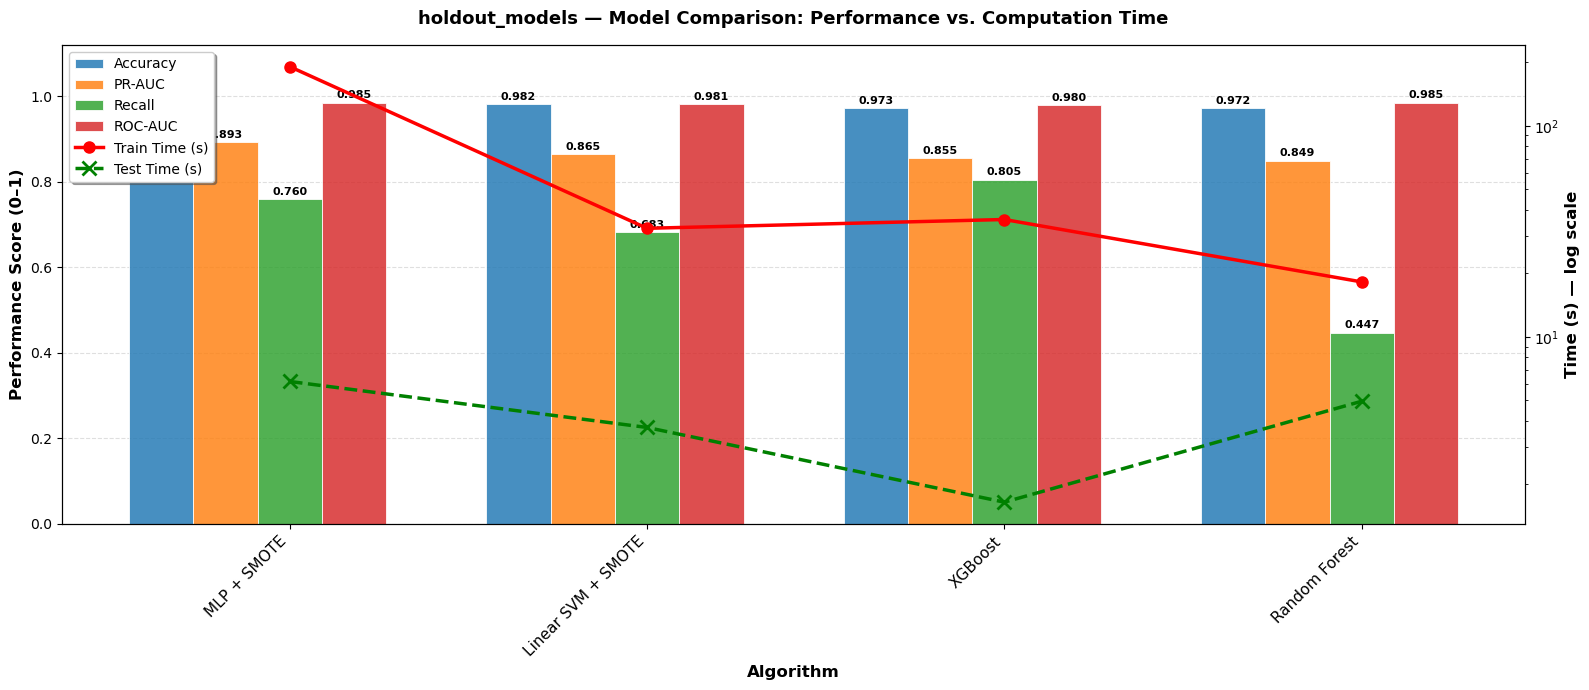

In [ ]:
visualize_metrics_graph(holdout_df, 'holdout_models')

### Section 5: Improving the Model

#### Hyperparameter Tuning Strategy

**RandomizedSearchCV** was used over GridSearchCV due to computational constraints. GridSearchCV exhaustively evaluates every parameter combination — for the MLP alone, the defined grid produces 300+ configurations, each requiring 5-fold cross-validation with SMOTE resampling. Across four models, this would result in thousands of fits and an estimated runtime exceeding 24 hours. RandomizedSearchCV samples a fixed number of parameter combinations (50 per model), achieving comparable tuning quality in a fraction of the time.

**PR-AUC (Precision-Recall Area Under Curve)** was selected as the scoring metric instead of accuracy or ROC-AUC because the EMSCAD dataset is heavily imbalanced (~95% legitimate, ~5% fraudulent). In this setting:

- **Accuracy** is misleading — a model predicting all postings as legitimate achieves 95% accuracy while catching zero fraud.
- **ROC-AUC** can appear inflated because it incorporates the true negative rate, which is trivially high when the majority class dominates.
- **PR-AUC** focuses exclusively on the minority (fraud) class by measuring the trade-off between precision and recall, making it the most honest metric for evaluating how well each model identifies fraudulent postings without excessive false alarms.

In [ ]:
# ── Param distributions (RandomizedSearchCV-compatible) ───────────────────────
tuning_param_grids = {
    "MLP + SMOTE": {
        "model__hidden_layer_sizes": [
            (256, 128),
            (512, 256),
            (256, 128, 64),
            (512, 256, 128),
            (128, 64),
        ],
        "model__alpha": loguniform(1e-4, 1e-1),             # L2 regularisation strength
        "model__learning_rate_init": loguniform(1e-4, 1e-2),
        "model__batch_size": [128, 256, 512],
        "model__activation": ["relu", "tanh"],
    },
    "Linear SVM + SMOTE": {
        "model__estimator__C": [0.1, 0.5, 1.0, 5.0, 10.0], # estimator__ because of CalibratedClassifierCV wrapper
        "model__estimator__max_iter": [2000, 5000],
        "smote__k_neighbors": [3, 5, 7]                     # also tune SMOTE's neighborhood size
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],                     # row subsampling — reduces overfitting
        "model__colsample_bytree": [0.8, 1.0]               # feature subsampling per tree
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]             # controls feature diversity per split
    },
}

# ── Pipeline builders per model ───────────────────────────────────────────────
def build_tuning_pipe(name, model):
    if name in ["Linear SVM + SMOTE", "MLP + SMOTE"]:
        return ImbPipeline(steps=[
            ("preprocess", preprocessor_svm),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model)
        ])
    elif name == "XGBoost":                                  # tree preprocessor for XGBoost
        return Pipeline(steps=[
            ("preprocess", preprocessor_tree),
            ("model", model)
        ])
    else:                                                    # Random Forest
        return Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])

# ── Model instances (fresh, unfit) ───────────────────────────────────────────
tuning_model_instances = {
    "MLP + SMOTE": MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ),
    "Linear SVM + SMOTE": CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE)
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

# ── n_iter per model (controls search budget) ────────────────────────────────
tuning_n_iter = {
    "MLP + SMOTE": 15,          # expensive — keep low
    "Linear SVM + SMOTE": 20,   # small grid, can afford more
    "XGBoost": 20,
    "Random Forest": 20,
}

# ── Tuning loop ───────────────────────────────────────────────────────────────
best_models = {}

tuning_df: pd.DataFrame
TUNED_MODELS_PATH = 'data/tuned_models.csv'

if os.path.exists(TUNED_MODELS_PATH):
    print("Found existing tuned_models.csv — loading results and reconstructing best_models...")
    tuning_df = pd.read_csv(TUNED_MODELS_PATH)
    tuning_rows = tuning_df.to_dict(orient='records')

    for _, row in tuning_df.iterrows():
        # Strip "Tuned " prefix to match original model name key
        name = row['model'].removeprefix('Tuned ')
        if name not in tuning_model_instances:
            print(f"  Skipping '{name}' — not found in tuning_model_instances")
            continue

        best_params = eval(row['best_params'])
        X_input = get_X_for_model(name)
        pipe = build_tuning_pipe(name, tuning_model_instances[name])

        pipe.set_params(**best_params)
        pipe.fit(X_input, y_train)

        best_models[name] = pipe
        print(f"  ✔ Reconstructed best model for: {name}")

else:
    print("No cached results found — running full randomized search...")
    
    tuning_rows = []

    for name, model in tuning_model_instances.items():
        print(f"\nPerforming randomized search for {name}")
        X_input = get_X_for_model(name)
        pipe = build_tuning_pipe(name, model)

        search = RandomizedSearchCV(
            pipe,
            param_distributions=tuning_param_grids[name],
            n_iter=tuning_n_iter[name],
            scoring="average_precision",
            cv=cv,
            n_jobs=1 if name == "MLP + SMOTE" else -1,
            verbose=1,
            random_state=RANDOM_STATE,
            refit=True
        )

        search.fit(X_input, y_train)
        best_models[name] = search.best_estimator_

        tuning_rows.append({
            "model": f"Tuned {name}",
            "best_pr_auc_cv": search.best_score_,
            "best_params": search.best_params_,
            "train_time_s": search.cv_results_["mean_fit_time"].mean(),
            "score_time_s": search.cv_results_["mean_score_time"].mean()
        })

    tuning_df = (
        pd.DataFrame(tuning_rows)
        .sort_values("best_pr_auc_cv", ascending=False)
        .reset_index(drop=True)
    )
    tuning_df.to_csv(TUNED_MODELS_PATH, index=False)

tuning_df

Found existing tuned_models.csv — loading results and reconstructing best_models...
  ✔ Reconstructed best model for: MLP + SMOTE
  ✔ Reconstructed best model for: XGBoost
  ✔ Reconstructed best model for: Linear SVM + SMOTE
  ✔ Reconstructed best model for: Random Forest


,Unnamed: 0,model,best_pr_auc_cv,best_params,train_time_s,score_time_s
0,0,Tuned MLP + SMOTE,0.898816,"{'model__activation': 'relu', 'model__alpha': ...",131.003688,1.334540
1,1,Tuned XGBoost,0.885382,"{'model__subsample': 0.8, 'model__n_estimators...",101.864381,4.615629
2,2,Tuned Linear SVM + SMOTE,0.865303,"{'smote__k_neighbors': 5, 'model__estimator__m...",55.034650,4.212596
3,3,Tuned Random Forest,0.858598,"{'model__n_estimators': 500, 'model__min_sampl...",22.001535,4.841336


In [152]:
tuned_rf = best_models.get("Random Forest")

X_test_rf = X_tree_test   # Random Forest uses tree preprocessor — no get_X_for_model needed for test

# ── Predict on holdout set ────────────────────────────────────────────────────
rf_pred = tuned_rf.predict(X_test_rf)
rf_proba = tuned_rf.predict_proba(X_test_rf)[:, 1]

# ── Compute metrics ───────────────────────────────────────────────────────────
accuracy_rf = accuracy_score(y_test, rf_pred)
precision_rf = precision_score(y_test, rf_pred, zero_division=0)
recall_rf = recall_score(y_test, rf_pred, zero_division=0)
f1_rf = f1_score(y_test, rf_pred, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, rf_proba)
pr_auc_rf = average_precision_score(y_test, rf_proba)

# ── Build summary row ─────────────────────────────────────────────────────────
tuned_rf_metrics = {
    "model":  "Tuned Random Forest",
    "accuracy": accuracy_rf,
    "precision": precision_rf,
    "recall": recall_rf,
    "f1": f1_rf,
    "roc_auc": roc_auc_rf,
    "precision_recall_auc": pr_auc_rf,      
    "Train Time (s)": tuning_df[tuning_df['model'] == "Tuned Random Forest"]['train_time_s'].values[0],
    "Test Time (s)": tuning_df[tuning_df['model'] == "Tuned Random Forest"]['score_time_s'].values[0]
}
tuned_rf_df = pd.DataFrame([tuned_rf_metrics])
display(tuned_rf_df)

# ── Combine with holdout baseline results ─────────────────────────────────────
comparison_df = pd.concat(
    [holdout_df[holdout_df["model"] != "Random Forest"], tuned_rf_df],
    ignore_index=True
)

# ── Sort by PR-AUC — use the actual column name ───────────────────────────────
comparison_df = (
    comparison_df
    .sort_values(by="precision_recall_auc", ascending=False)   # ← was "pr_auc" (KeyError)
    .reset_index(drop=True)
)

# ── Summary print ─────────────────────────────────────────────────────────────
print("\n--- Comparison Summary ---\n")
print(
    f"Tuned Random Forest — PR-AUC: {pr_auc_rf:.4f} | "
    f"F1: {f1_rf:.4f} | ROC-AUC: {roc_auc_rf:.4f}"
)

# ── CV vs holdout gap ─────────────────────────────────────────────────────────
if "tuning_df" in dir() and (tuning_df["model"] == "Tuned Random Forest").any():
    cv_pr_auc = tuning_df.loc[tuning_df["model"] == "Tuned Random Forest", "best_pr_auc_cv"].iloc[0]
    print(
        f"CV PR-AUC (tuning): {cv_pr_auc:.4f}  →  Holdout PR-AUC: {pr_auc_rf:.4f}  "
        f"({'↑ generalises well' if pr_auc_rf >= cv_pr_auc else '↓ some overfitting'})"
    )

# ── Delta vs untuned baseline ─────────────────────────────────────────────────
if (holdout_df["model"] == "Random Forest").any():
    old_pr = holdout_df.loc[holdout_df["model"] == "Random Forest", "precision_recall_auc"].iloc[0]
    print(
        f"Untuned Random Forest PR-AUC: {old_pr:.4f}  →  "
        f"Delta: {pr_auc_rf - old_pr:+.4f}"
    )

display(comparison_df)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,Tuned Random Forest,0.972036,1.0,0.421965,0.593496,0.98906,0.895002,22.001535,4.841336



--- Comparison Summary ---

Tuned Random Forest — PR-AUC: 0.8950 | F1: 0.5935 | ROC-AUC: 0.9891
CV PR-AUC (tuning): 0.8586  →  Holdout PR-AUC: 0.8950  (↑ generalises well)
Untuned Random Forest PR-AUC: 0.8493  →  Delta: +0.0457


,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,Tuned Random Forest,0.972036,1.000000,0.421965,0.593496,NaN,0.989060,0.895002,22.001535,4.841336
1,MLP + SMOTE,0.983571,0.884823,0.760411,0.817573,0.982977,0.985180,0.892805,150.979876,4.034142
2,Linear SVM + SMOTE,0.981614,0.917064,0.682577,0.782334,0.980318,0.980625,0.865099,33.487398,4.570332
3,XGBoost,0.972944,0.689869,0.805182,0.742618,0.973941,0.980110,0.854797,55.260767,2.441590


In [ ]:
for _, row in tuning_df.iterrows():
    print(f"\n{'='*50}")
    print(f"Model: {row['model']}")
    print(f"Model fit time: {row['train_time_s']:.4f} seconds")
    print(f"Best PR AUC CV: {row['best_pr_auc_cv']:.4f}")
    print(f"Best Params:")
    for param, value in eval(row['best_params']).items():
        print(f"  {param}: {value}")


Model: Tuned MLP + SMOTE
Model fit time: 131.0037 seconds
Best PR AUC CV: 0.8988
Best Params:
  model__activation: relu
  model__alpha: 0.00033120277014659456
  model__batch_size: 128
  model__hidden_layer_sizes: (512, 256, 128)
  model__learning_rate_init: 0.00023145798905204883

Model: Tuned XGBoost
Model fit time: 101.8644 seconds
Best PR AUC CV: 0.8854
Best Params:
  model__subsample: 0.8
  model__n_estimators: 500
  model__max_depth: 8
  model__learning_rate: 0.1
  model__colsample_bytree: 1.0

Model: Tuned Linear SVM + SMOTE
Model fit time: 55.0346 seconds
Best PR AUC CV: 0.8653
Best Params:
  smote__k_neighbors: 5
  model__estimator__max_iter: 5000
  model__estimator__C: 1.0

Model: Tuned Random Forest
Model fit time: 22.0015 seconds
Best PR AUC CV: 0.8586
Best Params:
  model__n_estimators: 500
  model__min_samples_split: 2
  model__min_samples_leaf: 1
  model__max_features: log2
  model__max_depth: None


In [ ]:
test_rows = []

for name, est in best_models.items():
    X_input = get_X_for_model(name, split='test')   
    pred = est.predict(X_input)
    proba = est.predict_proba(X_input)[:, 1]

    test_rows.append({
        "model": f"Tuned {name}",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":  recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "precision_recall_auc": average_precision_score(y_test, proba),
        "Train Time (s)": tuning_df.loc[tuning_df["model"] == f"Tuned {name}", "train_time_s"].values[0],
        "Test Time (s)": tuning_df.loc[tuning_df["model"] == f"Tuned {name}", "score_time_s"].values[0],
    })

test_df = (
    pd.DataFrame(test_rows)
    .sort_values("precision_recall_auc", ascending=False)
    .reset_index(drop=True)
)
test_df

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib

,model,accuracy,precision,recall,f1,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,Tuned MLP + SMOTE,0.986857,0.925676,0.791908,0.853583,0.990751,0.925727,131.003688,1.334540
1,Tuned XGBoost,0.987416,0.957143,0.774566,0.856230,0.989374,0.917582,101.864381,4.615629
2,Tuned Linear SVM + SMOTE,0.982383,0.916667,0.699422,0.793443,0.987325,0.911166,55.034650,4.212596
3,Tuned Random Forest,0.972036,1.000000,0.421965,0.593496,0.989060,0.895002,22.001535,4.841336


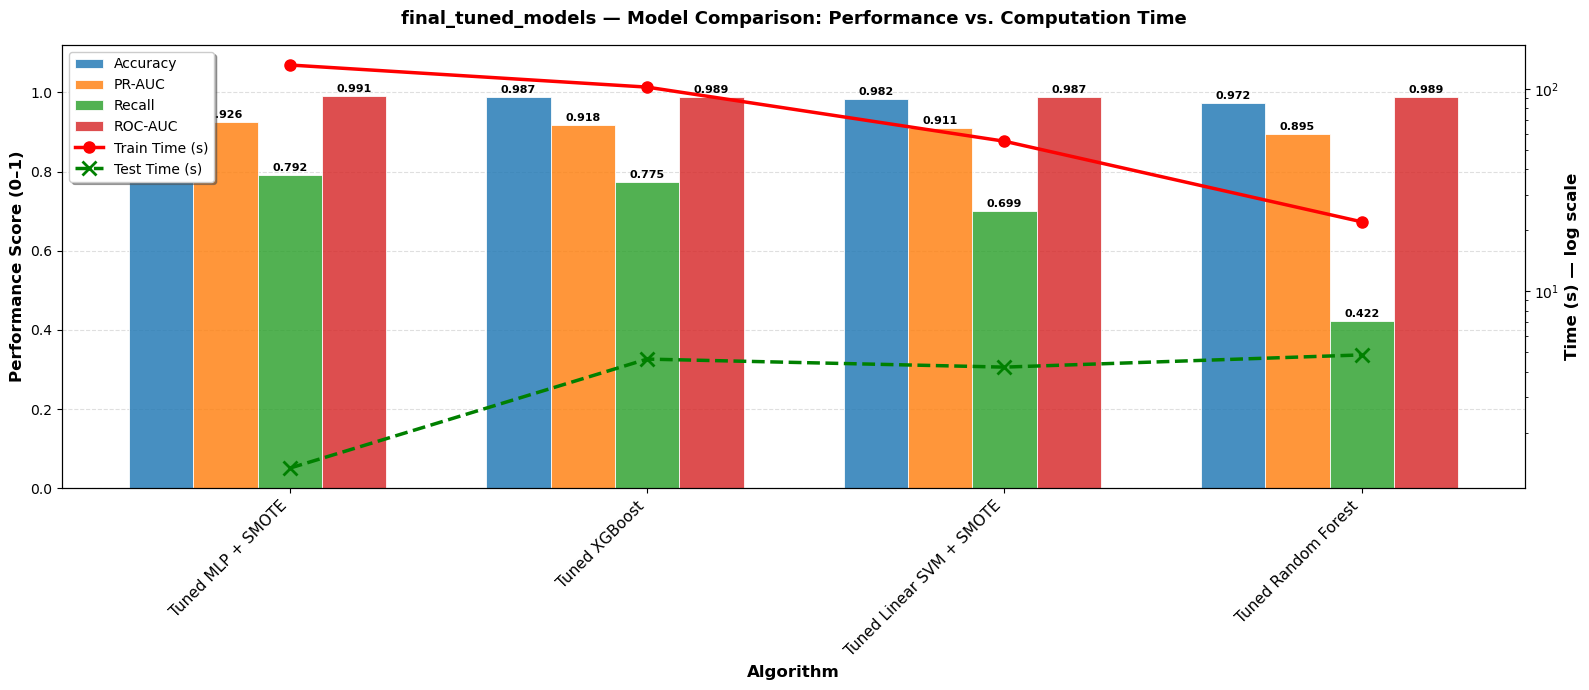

In [ ]:
visualize_metrics_graph(test_df, 'final_tuned_models')

### Section 6: Final Model Decision

Selected final model: Tuned MLP + SMOTE


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


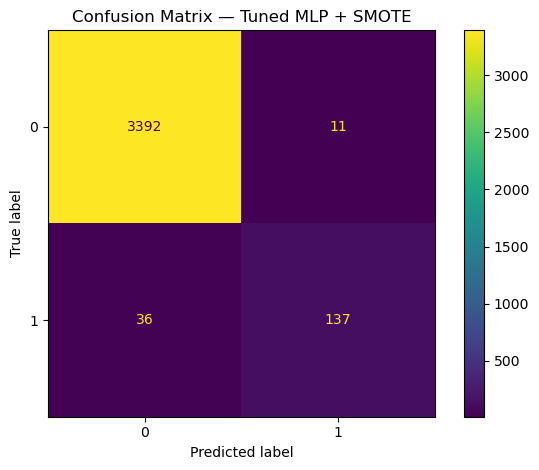

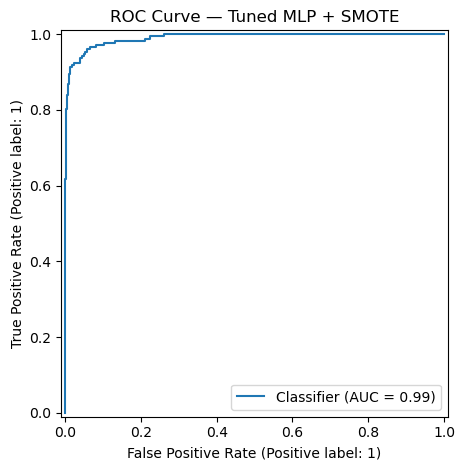

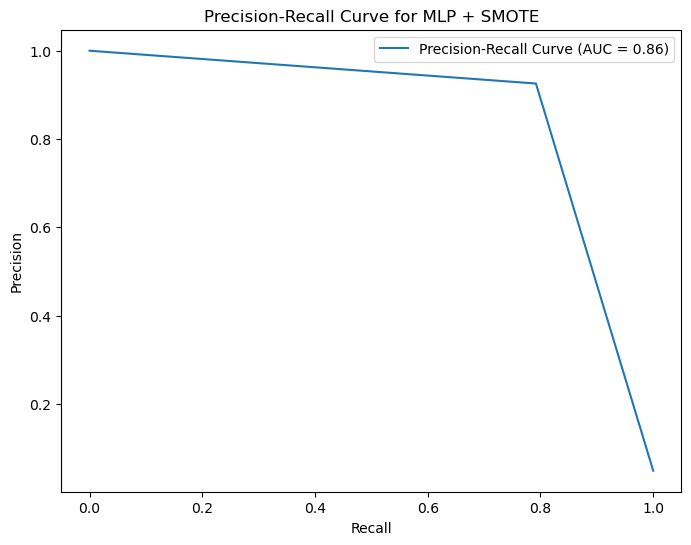

In [ ]:
final_model_name = test_df.loc[0, "model"]
final_base_name = final_model_name.replace("Tuned ", "")
final_model = best_models[final_base_name]

print("Selected final model:", final_model_name)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, values_format="d")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_confusion_matrix.png')
plt.show()

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_roc_auc_curve.png')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, final_pred)
auc_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for MLP + SMOTE')
plt.legend()
plt.show()

### Section 7: Feature Importances

Given the model coefficients, attain the list of features that strongly indicated fraudulency.

In [ ]:
# ── Helper: get feature names after preprocessing ─────────────────────────────
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocess']
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        return X_train.columns.tolist()

# ── 1. Linear SVM — coefficients via CalibratedClassifierCV ──────────────────
svm_pipeline  = best_models["Linear SVM + SMOTE"]
feature_names = get_feature_names(svm_pipeline)

# CalibratedClassifierCV wraps LinearSVC — coefficients live in calibrated_classifiers_
base_clf      = svm_pipeline.named_steps["model"]           # CalibratedClassifierCV
inner_svc     = base_clf.calibrated_classifiers_[0].estimator  # LinearSVC

if inner_svc.coef_.shape[0] == 1:                           # binary
    coef_values = inner_svc.coef_[0]
else:                                                        # multiclass — average abs coef
    coef_values = np.mean(np.abs(inner_svc.coef_), axis=0)

coef_svm_df = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": coef_values
}).sort_values(by="coefficient", key=np.abs, ascending=False).reset_index(drop=True)

print("\nCoefficients from Linear SVM:")
display(coef_svm_df.head(15))

# ── 2. Random Forest — native feature importances ────────────────────────────
rf_pipeline   = best_models["Random Forest"]
rf_model      = rf_pipeline.named_steps["model"]
feature_names = get_feature_names(rf_pipeline)

feature_importance_rf_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nFeature Importances from Random Forest:")
display(feature_importance_rf_df.head(15))

# ── 3. XGBoost — native feature importances (gain) ───────────────────────────
xgb_pipeline  = best_models["XGBoost"]
xgb_model     = xgb_pipeline.named_steps["model"]
feature_names = get_feature_names(xgb_pipeline)

feature_importance_xgb_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": xgb_model.feature_importances_            # default: 'weight'; gain available via get_booster()
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nFeature Importances from XGBoost:")
display(feature_importance_xgb_df.head(15))

# ── 4. MLP — permutation importance (no native coef interpretation) ───────────
mlp_pipeline  = best_models["MLP + SMOTE"]
X_test_mlp    = get_X_for_model("MLP + SMOTE", split="test")

result_mlp = permutation_importance(
    mlp_pipeline, X_test_mlp, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="average_precision"
)

# Permutation importance shuffles pipeline *inputs* — use raw column names
perm_importances_mlp_df = pd.DataFrame({
    "feature":    X_test_mlp.columns.tolist(),              # ← raw features, not preprocessed
    "importance": result_mlp.importances_mean,
    "std":        result_mlp.importances_std
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nPermutation Importances from MLP:")
display(perm_importances_mlp_df.head(15))


Coefficients from Linear SVM:


,feature,coefficient
0,tfidf_text__link,2.391009
1,tfidf_text__company_profile,2.209792
2,cat__department_Information Technology,1.801969
3,tfidf_text__american,1.792865
4,tfidf_text__aptitude,1.739656
5,tfidf_text__supply,1.648698
6,tfidf_text__executive,1.636380
7,cat__department_biotech,1.568771
8,tfidf_text__money,1.497633
9,tfidf_text__ohio,1.393641



Feature Importances from Random Forest:


,feature,importance
0,tfidf_text__company_profile,0.024124
1,num__company_profile_wc,0.018535
2,num__company_profile_len,0.016572
3,tfidf_text__unknown,0.009747
4,tfidf_text__value,0.008886
5,tfidf_text__team,0.007298
6,tfidf_text__benefits,0.006086
7,tfidf_text__growing,0.006054
8,tfidf_text__web,0.005957
9,num__description_wc,0.005474



Feature Importances from XGBoost:


,feature,importance
0,tfidf_text__000,0.026621
1,num__company_profile_len,0.024032
2,tfidf_text__hiring,0.015136
3,cat__department_Accounting/Payroll,0.014847
4,tfidf_title__professional,0.013866
5,tfidf_title__division,0.013715
6,tfidf_title__tester,0.011337
7,cat__industry_Biotechnology,0.011242
8,cat__required_education_High School or equivalent,0.011010
9,tfidf_text__communications,0.010226


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/pytho


Permutation Importances from MLP:


,feature,importance,std
0,text,0.579415,0.024180
1,title,0.071422,0.007745
2,industry,0.032840,0.005003
3,department,0.025172,0.004432
4,missing_count,0.018663,0.003759
5,function,0.008581,0.003316
6,company_profile_len,0.007447,0.004684
7,required_education,0.006894,0.002884
8,company_profile_wc,0.006569,0.004209
9,employment_type,0.003091,0.001512


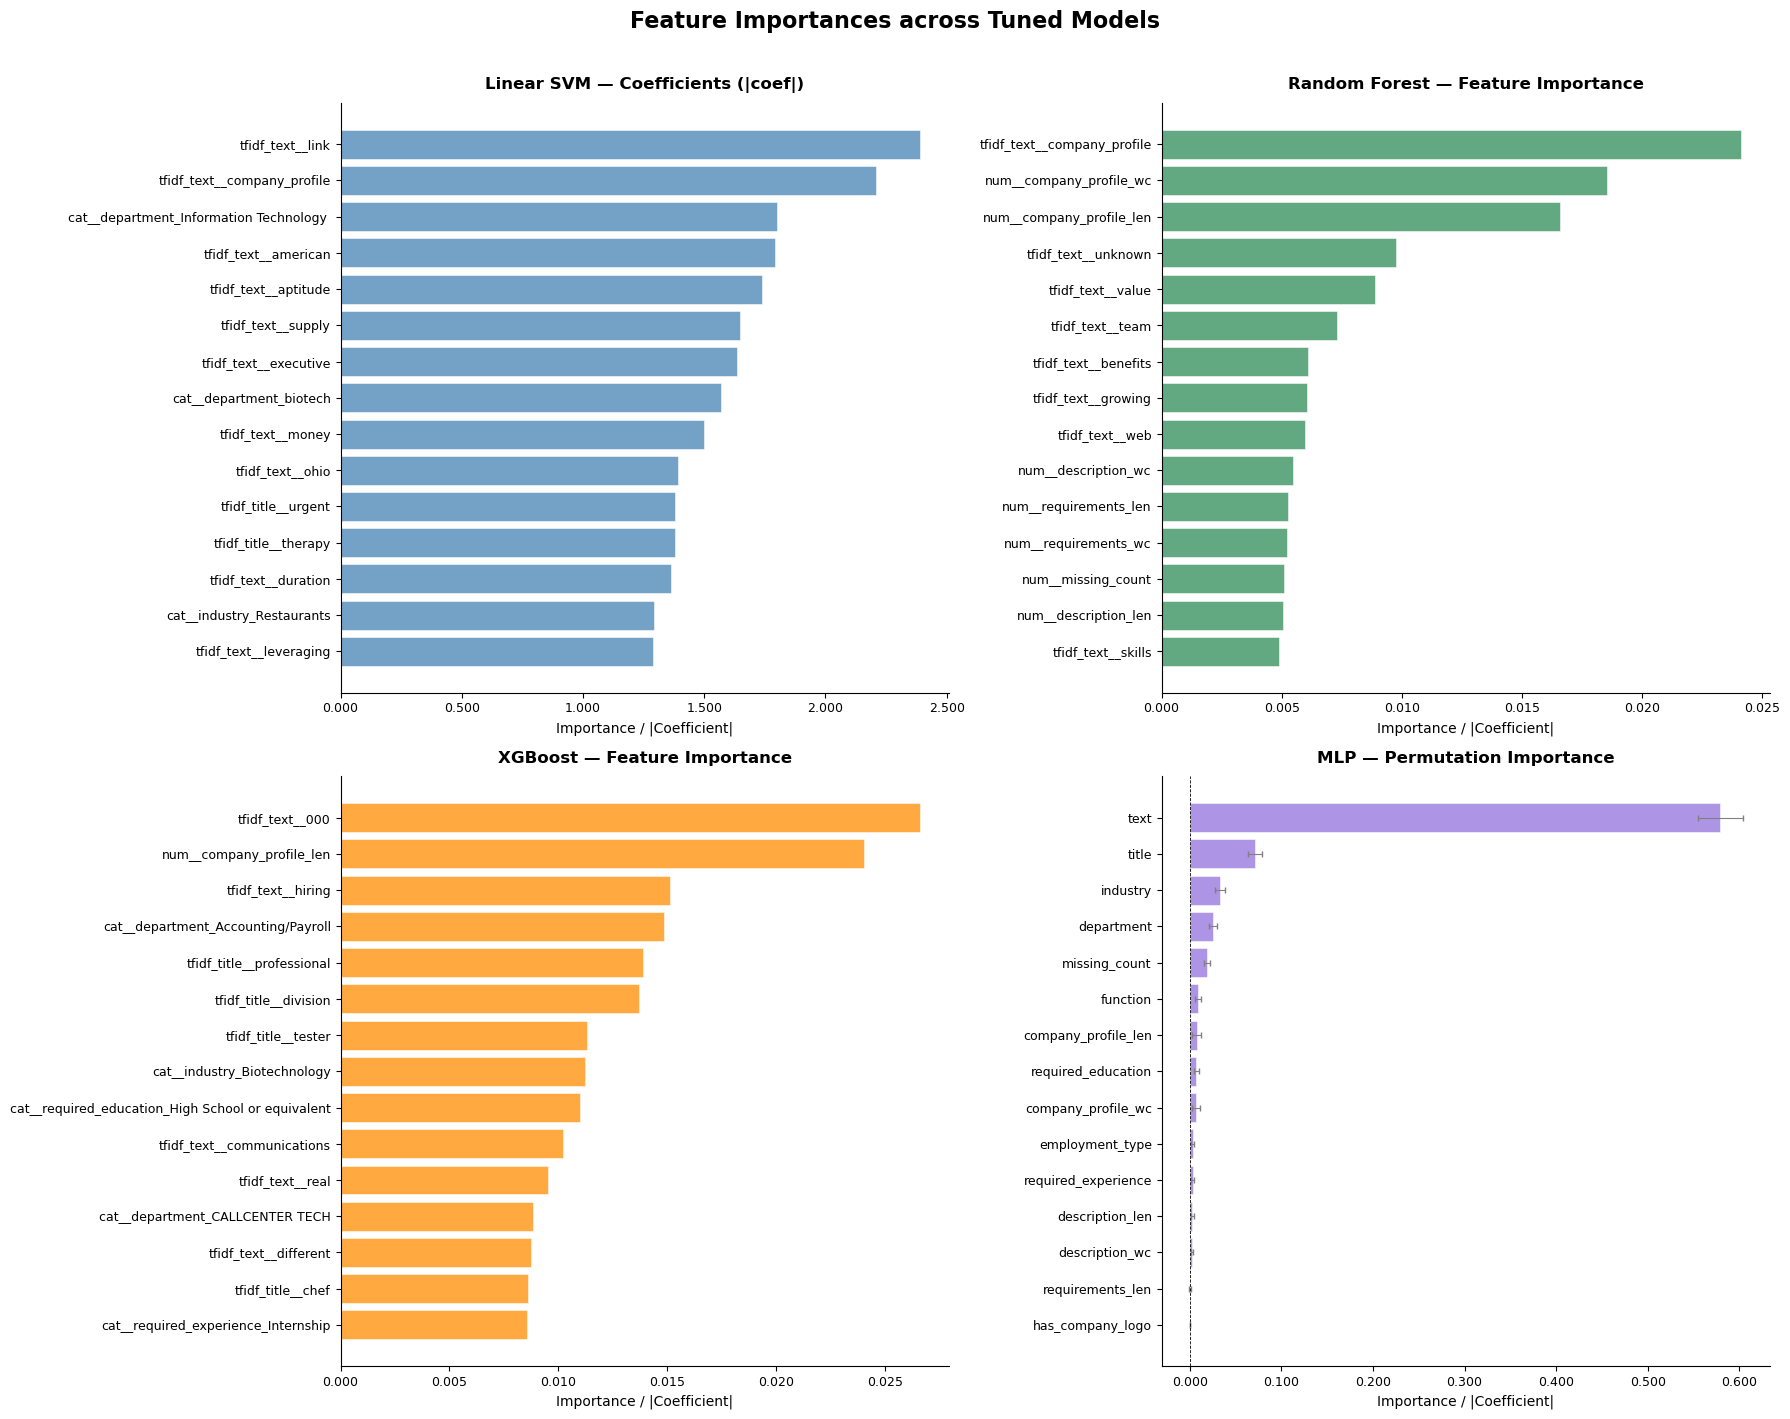

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Feature Importances across Tuned Models", fontsize=16, fontweight="bold", y=1.01)

# ── Shared style config ───────────────────────────────────────────────────────
TOP_N   = 15
configs = [
    {
        "ax": axes[0, 0],
        "df": coef_svm_df.head(TOP_N),
        "x_col": "coefficient",
        "label": "Linear SVM — Coefficients (|coef|)",
        "color": "steelblue",
        "abs": True,                                    # SVM coefs can be negative
    },
    {
        "ax": axes[0, 1],
        "df": feature_importance_rf_df.head(TOP_N),
        "x_col": "importance",
        "label": "Random Forest — Feature Importance",
        "color": "seagreen",
        "abs": False,
    },
    {
        "ax": axes[1, 0],
        "df": feature_importance_xgb_df.head(TOP_N),
        "x_col": "importance",
        "label": "XGBoost — Feature Importance",
        "color": "darkorange",
        "abs": False,
    },
    {
        "ax": axes[1, 1],
        "df": perm_importances_mlp_df.head(TOP_N),
        "x_col": "importance",
        "label": "MLP — Permutation Importance",
        "color": "mediumpurple",
        "abs": False,
        "std_col": "std",                                   # MLP has std — draw error bars
    },
]

for cfg in configs:
    ax = cfg["ax"]
    df = cfg["df"].copy()
    x_col = cfg["x_col"]
    values = df[x_col].abs() if cfg.get("abs") else df[x_col]

    # Sort descending for clean horizontal bar layout
    df = df.assign(_val=values).sort_values("_val", ascending=True)
    values = df["_val"]

    xerr = df[cfg["std_col"]] if "std_col" in cfg else None

    ax.barh(
        df["feature"], values,
        xerr=xerr,
        color=cfg["color"],
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5,
        error_kw={"elinewidth": 0.8, "ecolor": "grey", "capsize": 2}
    )

    ax.set_title(cfg["label"], fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Importance / |Coefficient|", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.savefig("images/feature_importance_tuned_models.png", dpi=150, bbox_inches="tight")
plt.show()

### Section 8: Key Findings

By using SMOTE to balance the ratio of legitimate to fraudulent job postings to 1:1, the Logistic Regression model performed decently, with an ROC AUC score of ~0.8591 and an F1 score of ~0.7125.

The feature importances graph furthermore indicates the following:
- Information Technology increases the chance of fraudulency, which falls in line with my own personal experience of encountering various fraudulent opportunities. Words, like internet, engineering, computer networking, seem to validate this.
- Sales and Research, Oil & Energy, Product Development, Engineering also indicate positive coefficients for fraudulency. Could Smote's oversampling of the fraudulent class also increased the number of these occurrences?
- "Achieve" in a job description could be a key word fraudulent job postings use to mimic legitimate postings.
- Any mentions of team, website, growing (however close this is to 'achieve') affected the coefficients towards legitimacy, perhaps due to sharper specificity of company lingo.
- "Level" may suggest that indication of seniority in a job posting correlates more with legitimate job postings.

### Section 9: Next Steps

Per next steps of this project, consider threshold tuning for the Logistic Regression Model so it can more aggressively identify fraudulent job postings, with a cost of moderate increase in false positives. 

Other models like XGBoost could capture non-linear feature interactions better than the former, and pre-trained models like BERT could contextualize 
encouraging buzz word language often used in fraudulent job postings. 

This model could also benefit from feature enrichment through two datasets:
- The [UCI SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection), which could expand the model to other language commonly used in fraud attempts
- the [Linkedin Job Postings Dataset](https://huggingface.co/datasets/datastax/linkedin_job_listings), while unclassified for legitimate vs. fraudulent job descriptions, could contextualize the model with structured and text features that could complement the EMSCAD schema